# Praktikum Bab 07: Evaluasi Model
Praktikum mingguan, mulai dari Implementasi Python. Dijalankan di Google Colab, tinggal **Runtime > Run all**.

### Sel 0 - Persiapan Awal (Khusus Google Colab)

Kalau notebook ini dibuka di Google Colab lewat link GitHub, jalankan sel di bawah ini dulu (atau langsung **Runtime > Run all**). Sel ini cuma memastikan semua paket yang dibutuhkan sudah tersedia. Bab ini tidak butuh file data apa pun karena dataset Breast Cancer dimuat langsung dari scikit-learn, jadi kalau dijalankan di laptop pun sel ini tidak mengubah apa-apa.

In [1]:
# Sel 0 - Persiapan awal (jalan otomatis paling awal saat Run All).
# Bab 7 tidak membutuhkan file data eksternal: dataset Breast Cancer
# dimuat langsung dari sklearn.datasets. Sel ini hanya memastikan
# semua paket yang dibutuhkan sudah tersedia.
import importlib

for _paket in ["sklearn", "pandas", "numpy", "matplotlib"]:
    importlib.import_module(_paket)
    print(f"OK: {_paket} tersedia.")

print("Paket siap.")

OK: sklearn tersedia.
OK: pandas tersedia.
OK: numpy tersedia.


OK: matplotlib tersedia.
Paket siap.


### Praktikum 1 - Laporan Evaluasi Lengkap

**Tujuan:** saya bisa menyusun laporan evaluasi model yang komprehensif.

**Instruksi (modul):** memakai dataset `load_breast_cancer`, latih model Logistic Regression dan Decision Tree. Buat confusion matrix, hitung precision/recall/F1 untuk keduanya, serta buat ROC curve dan PR curve dalam satu grafik untuk membandingkan kedua model.

Pertama saya siapkan dulu datanya: muat dataset Breast Cancer, lalu bagi jadi data latih dan data uji dengan `test_size=0.2` dan `random_state=42`. Setelah itu saya latih dua modelnya, Logistic Regression (`max_iter=5000`) dan Decision Tree (`random_state=42`).

In [2]:
# Praktikum 1 - Persiapan data dan model
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

data = load_breast_cancer()
X, y = data.data, data.target
print(f"Dataset: {X.shape[0]} pasien, {X.shape[1]} fitur")
print(f"Kelas: {dict(zip(data.target_names, np.bincount(y)))}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Data latih: {X_train.shape[0]} baris, data uji: {X_test.shape[0]} baris")

model_lr = LogisticRegression(max_iter=5000)
model_dt = DecisionTreeClassifier(random_state=42)
model_lr.fit(X_train, y_train)
model_dt.fit(X_train, y_train)
print("Kedua model berhasil dilatih.")

Dataset: 569 pasien, 30 fitur
Kelas: {np.str_('malignant'): np.int64(212), np.str_('benign'): np.int64(357)}
Data latih: 455 baris, data uji: 114 baris


Kedua model berhasil dilatih.


**Penjelasan outputnya:**
- Dataset Breast Cancer yang saya pakai ternyata berisi **569 pasien dengan 30 fitur**, terbagi jadi 212 pasien malignant (ganas) dan 357 pasien benign (jinak).
- Setelah di-split, data latihnya **455 baris** dan data ujinya **114 baris**, sesuai `test_size=0.2`.
- Kedua model (Logistic Regression dan Decision Tree) berhasil dilatih tanpa error, jadi saya bisa lanjut ke evaluasi.

Terus saya cetak `classification_report` buat kedua model supaya precision, recall, dan F1-nya kelihatan per kelas.

In [3]:
# Praktikum 1 - Classification report kedua model
from sklearn.metrics import classification_report

for nama, model in [("Logistic Regression", model_lr), ("Decision Tree", model_dt)]:
    print(f"=== {nama} ===")
    print(classification_report(y_test, model.predict(X_test),
                                target_names=data.target_names))

=== Logistic Regression ===
              precision    recall  f1-score   support

   malignant       0.97      0.91      0.94        43
      benign       0.95      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

=== Decision Tree ===
              precision    recall  f1-score   support

   malignant       0.93      0.93      0.93        43
      benign       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



**Penjelasan outputnya:**
- **Logistic Regression** dapat akurasi **0.96**. Untuk kelas malignant: precision 0.97, recall 0.91, F1 0.94. Untuk kelas benign: precision 0.95, recall 0.99, F1 0.97. Artinya model ini hampir tidak pernah salah menandai pasien jinak sebagai ganas (recall benign 0.99), tapi masih melewatkan sedikit kasus ganas (recall malignant 0.91).
- **Decision Tree** dapat akurasi **0.95**, sedikit di bawah Logistic Regression. Skornya seimbang di kedua kelas: malignant precision/recall/F1 semuanya 0.93, benign semuanya 0.96.
- Dari dua laporan ini, Logistic Regression unggul tipis, terutama di precision kelas malignant (0.97 lawan 0.93).

Selanjutnya saya tampilkan confusion matrix kedua model berdampingan biar gampang dibandingkan.

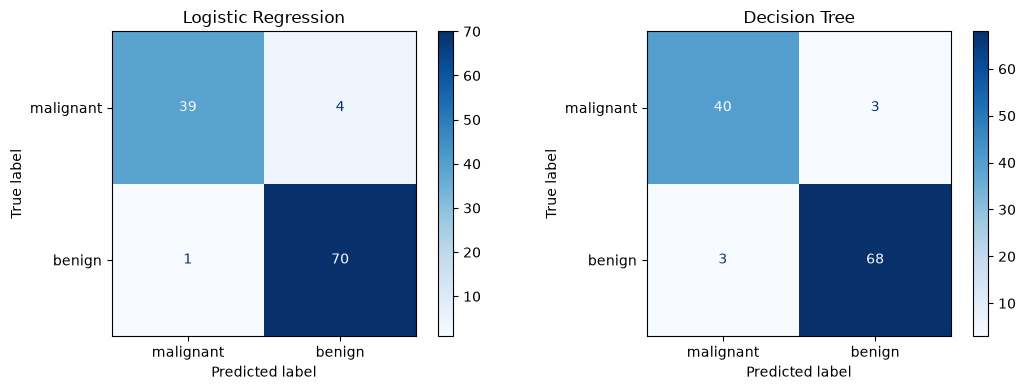

In [4]:
# Praktikum 1 - Confusion matrix berdampingan
from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, (nama, model) in zip(axes, [("Logistic Regression", model_lr),
                                    ("Decision Tree", model_dt)]):
    ConfusionMatrixDisplay.from_estimator(
        model, X_test, y_test, display_labels=data.target_names,
        cmap="Blues", ax=ax)
    ax.set_title(nama)
plt.tight_layout()
plt.show()

**Penjelasan outputnya:**
- Dari 114 data uji, **Logistic Regression cuma salah 5**: 4 pasien malignant yang kelewat diprediksi benign (false negative), dan 1 pasien benign yang salah diprediksi malignant (false positive).
- **Decision Tree salah 6**: 3 false negative dan 3 false positive, jadi kesalahannya terbagi rata di dua arah.
- Pola ini cocok sama classification report tadi: Logistic Regression memang sedikit lebih akurat (0.96 lawan 0.95).

Terakhir buat Praktikum 1, saya gambar ROC curve dan PR curve kedua model dalam satu figure (dua subplot berdampingan) sesuai instruksi modul.

Logistic Regression: AUC-ROC = 0.998, AUC-PR = 0.999
Decision Tree: AUC-ROC = 0.944, AUC-PR = 0.971


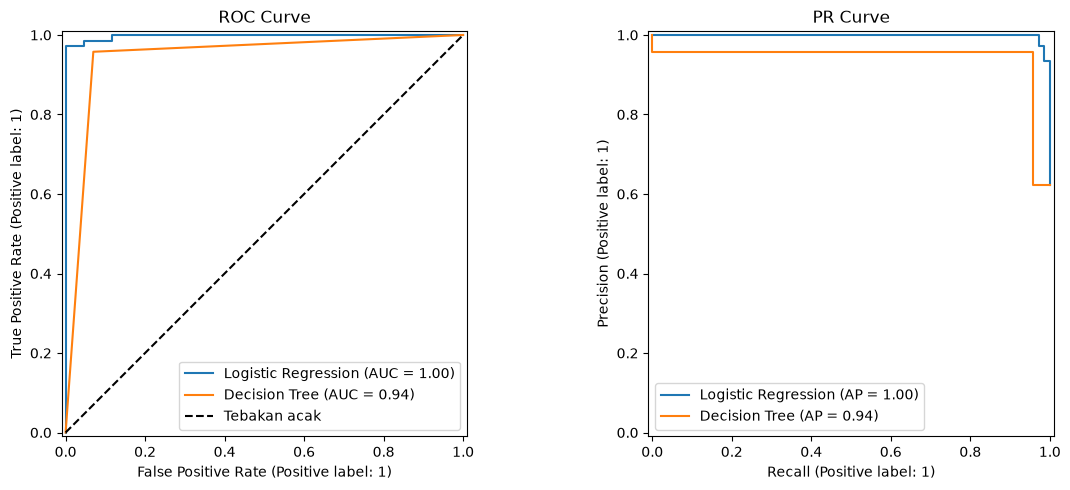

In [5]:
# Praktikum 1 - ROC curve dan PR curve dalam satu figure
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay, auc
from sklearn.metrics import roc_curve, precision_recall_curve

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
for nama, model in [("Logistic Regression", model_lr), ("Decision Tree", model_dt)]:
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax1, name=nama)
    PrecisionRecallDisplay.from_estimator(model, X_test, y_test, ax=ax2, name=nama)
    skor = model.predict_proba(X_test)[:, 1]
    print(f"{nama}: AUC-ROC = {auc(*roc_curve(y_test, skor)[:2]):.3f}, "
          f"AUC-PR = {auc(precision_recall_curve(y_test, skor)[1], precision_recall_curve(y_test, skor)[0]):.3f}")
ax1.set_title("ROC Curve")
ax2.set_title("PR Curve")
ax1.plot([0, 1], [0, 1], "k--", label="Tebakan acak")
ax1.legend()
plt.tight_layout()
plt.show()

**Penjelasan outputnya:**
- **Logistic Regression**: AUC-ROC **0.998** dan AUC-PR **0.999**. Kurvanya hampir nempel ke pojok kiri atas, artinya model ini memisahkan kedua kelas dengan nyaris sempurna di semua threshold.
- **Decision Tree**: AUC-ROC **0.944** dan AUC-PR **0.971**. Masih bagus, tapi kurvanya jelas berada di bawah Logistic Regression, terutama di ROC.
- **Kesimpulan Praktikum 1:** Logistic Regression lebih baik daripada Decision Tree di semua metrik (akurasi 0.96 lawan 0.95, AUC-ROC 0.998 lawan 0.944, AUC-PR 0.999 lawan 0.971). Masuk akal karena fitur-fitur Breast Cancer cenderung terpisah secara linear, jadi model linear seperti Logistic Regression sangat cocok di sini.

### Praktikum 2 - Perbandingan 3 Model dengan Stratified k-Fold CV

**Tujuan:** membandingkan performa 3 algoritma berbeda secara andal.

**Instruksi (modul, Praktikum 7.6):** bandingkan Logistic Regression, Decision Tree, dan KNN memakai `StratifiedKFold(n_splits=5, shuffle=True, random_state=42)` dengan `cross_val_score` dan `scoring="f1"`. Kode di bawah ini saya pakai persis dari modul, cuma saya lengkapi import yang kurang di baris paling atas.

In [6]:
# Praktikum 7.6 - Perbandingan 3 model dengan Stratified k-Fold CV (kode modul)
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score

model_list = { "Logistic Regression": LogisticRegression(max_iter=5000),
    "Decision Tree": DecisionTreeClassifier(max_depth=5,
    random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),}
skf = StratifiedKFold(n_splits=5,shuffle=True,
    random_state=42)
skor_cv = {}
for nama, model in model_list.items():
    skor = cross_val_score(model,X,y,cv=skf,scoring="f1")
    skor_cv[nama] = skor
    print(f"{nama}: F1 rata-rata = {skor.mean():.3f} (+/- {skor.std():.3f})")
# Tuliskan kesimpulan model mana yang paling baik dan paling stabil.

Logistic Regression: F1 rata-rata = 0.964 (+/- 0.014)
Decision Tree: F1 rata-rata = 0.944 (+/- 0.016)


KNN: F1 rata-rata = 0.949 (+/- 0.015)


**Penjelasan outputnya:**
- **Logistic Regression**: F1 rata-rata **0.964** (+/- 0.014). Tertinggi dari ketiganya.
- **Decision Tree** (max_depth=5): F1 rata-rata **0.944** (+/- 0.016). Paling rendah, tapi selisihnya tidak jauh.
- **KNN** (n_neighbors=5): F1 rata-rata **0.949** (+/- 0.015). Ada di tengah-tengah.
- Karena memakai StratifiedKFold 5 lipatan, tiap angka di atas adalah rata-rata dari 5 kali evaluasi dengan proporsi kelas yang terjaga, jadi lebih bisa dipercaya daripada sekali split.

Biar perbandingannya lebih gampang dibaca, saya gambar grafik batang F1 rata-rata plus standar deviasinya untuk ketiga model.

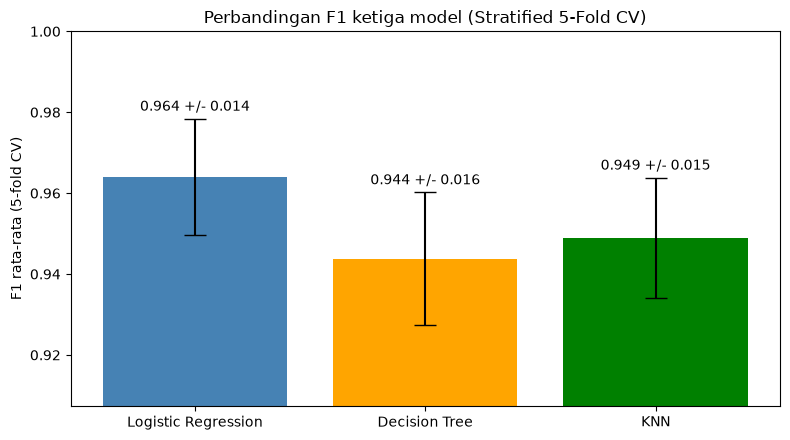

In [7]:
# Praktikum 2 - Grafik batang F1 rata-rata +/- std
nama_model = list(skor_cv.keys())
f1_mean = [skor_cv[n].mean() for n in nama_model]
f1_std = [skor_cv[n].std() for n in nama_model]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(nama_model, f1_mean, yerr=f1_std, capsize=8,
       color=["steelblue", "orange", "green"])
ax.set_ylim(min(f1_mean) - max(f1_std) - 0.02, 1.0)
ax.set_ylabel("F1 rata-rata (5-fold CV)")
ax.set_title("Perbandingan F1 ketiga model (Stratified 5-Fold CV)")
for n, m, s in zip(nama_model, f1_mean, f1_std):
    ax.text(n, m + s + 0.002, f"{m:.3f} +/- {s:.3f}", ha="center", fontsize=10)
plt.tight_layout()
plt.show()

**Penjelasan outputnya:**
- Grafik batangnya memperjelas urutannya: Logistic Regression paling tinggi (0.964), disusul KNN (0.949), lalu Decision Tree (0.944). Error bar (standar deviasi) ketiganya kecil, sekitar 0.014 sampai 0.016.
- **Kesimpulan Praktikum 2:** model yang **paling baik sekaligus paling stabil adalah Logistic Regression**, karena F1 rata-ratanya tertinggi (0.964) dan standar deviasinya terkecil (0.014). Artinya performanya tidak cuma bagus, tapi juga konsisten di semua lipatan. KNN jadi runner-up, sedangkan Decision Tree dengan max_depth=5 sedikit tertinggal, kemungkinan karena pembatasan kedalaman pohonnya.

## Percobaan Mandiri

Di bagian ini saya coba tiga percobaan tambahan sendiri soal evaluasi model: seberapa bisa dipercayanya hasil dari satu kali split, seberapa besar pengaruh `random_state`, dan kenapa akurasi bisa menipu di data yang tidak seimbang.


### Percobaan Mandiri 1: Single Split vs Cross-Validation

**Tujuan:** membuktikan bahwa akurasi dari satu kali `train_test_split` bisa menipu, sedangkan rata-rata cross-validation lebih stabil.

Saya latih `LogisticRegression` di Breast Cancer dengan dua cara: (1) satu split yang diulang dengan 5 seed berbeda, (2) `StratifiedKFold` 5 lipatan. Setup data dan model saya tulis ulang di cell ini.


In [8]:
# Percobaan Mandiri 1 - single split (5 seed) vs StratifiedKFold CV
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import (train_test_split, cross_val_score,
                                     StratifiedKFold)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Setup data: ditulis ulang di cell ini supaya mandiri
X, y = load_breast_cancer(return_X_y=True)

akurasi_single = []
for seed in [1, 2, 3, 4, 5]:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=seed)
    model = LogisticRegression(max_iter=5000)
    model.fit(X_train, y_train)
    akurasi_single.append(accuracy_score(y_test, model.predict(X_test)))

print("Akurasi single split (5 seed):",
      [f"{a:.4f}" for a in akurasi_single])
print(f"Rentang single split: {min(akurasi_single):.4f} - "
      f"{max(akurasi_single):.4f}")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
skor_cv = cross_val_score(LogisticRegression(max_iter=5000), X, y, cv=skf)
print("Skor tiap lipatan CV:", [f"{s:.4f}" for s in skor_cv])
print(f"Rata-rata CV: {skor_cv.mean():.4f} (+/- {skor_cv.std():.4f})")


Akurasi single split (5 seed): ['0.9474', '0.9298', '0.9386', '0.9123', '0.9649']
Rentang single split: 0.9123 - 0.9649


Skor tiap lipatan CV: ['0.9649', '0.9211', '0.9649', '0.9474', '0.9735']
Rata-rata CV: 0.9543 (+/- 0.0187)


**Penjelasan outputnya:**

- Lima single split menghasilkan akurasi **0.9474, 0.9298, 0.9386, 0.9123, 0.9649**, dengan rentang **0.9123** sampai **0.9649**. Hanya karena ganti seed, angkanya bisa selisih 0.0526.
- Cross-validation 5 lipatan memberi skor **0.9649, 0.9211, 0.9649, 0.9474, 0.9735** dengan rata-rata **0.9543** (+/- 0.0187).
- Kesimpulan saya: kalau cuma mengandalkan satu split, kita bisa dapat angka yang kebetulan bagus (atau kebetulan jelek) dan salah menilai model. CV memakai seluruh data secara bergiliran sebagai data uji, jadi estimasinya lebih stabil dan lebih bisa dipercaya.


### Percobaan Mandiri 2: Pengaruh random_state ke Hasil Split

**Tujuan:** melihat seberapa besar hasil evaluasi bisa berubah hanya karena ganti `random_state` di `train_test_split`.

Saya pakai `LogisticRegression` di Breast Cancer dengan tiga seed: 0, 42, dan 123. Selain akurasi test, saya catat juga komposisi kelas di data uji tiap seed, karena proporsi kelas yang kebagian di split juga ikut memengaruhi hasil.


In [9]:
# Percobaan Mandiri 2 - pengaruh random_state (0, 42, 123)
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Setup data: ditulis ulang di cell ini supaya mandiri
X, y = load_breast_cancer(return_X_y=True)

for seed in [0, 42, 123]:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=seed)
    model = LogisticRegression(max_iter=5000)
    model.fit(X_train, y_train)
    akurasi = accuracy_score(y_test, model.predict(X_test))
    n_malignant = int((y_test == 0).sum())
    n_benign = len(y_test) - n_malignant
    print(f"seed={seed:3d}: akurasi test = {akurasi:.4f}, "
          f"data uji = {len(y_test)} "
          f"(malignant: {n_malignant}, benign: {n_benign})")


seed=  0: akurasi test = 0.9474, data uji = 114 (malignant: 47, benign: 67)


seed= 42: akurasi test = 0.9561, data uji = 114 (malignant: 43, benign: 71)


seed=123: akurasi test = 0.9825, data uji = 114 (malignant: 41, benign: 73)


**Penjelasan outputnya:**

- seed=0: akurasi test **0.9474** (malignant: 47, benign: 67)
- seed=42: akurasi test **0.9561** (malignant: 43, benign: 71)
- seed=123: akurasi test **0.9825** (malignant: 41, benign: 73)
- Hanya dengan mengganti seed, akurasinya bergerak dalam rentang **0.9474** sampai **0.9825**, dan komposisi kelas di data uji pun ikut berubah-ubah. Ini menegaskan temuan percobaan sebelumnya: satu angka akurasi dari satu split tidak cukup untuk menyimpulkan, apalagi kalau mau membandingkan dua model.


### Percobaan Mandiri 3: Akurasi vs F1 di Data Imbalance

**Tujuan:** menunjukkan bahwa akurasi bisa menipu kalau datanya tidak seimbang.

Saya buat data sintetis dengan `make_classification`: 1000 baris, 95% kelas 0 dan 5% kelas 1. Lalu saya bandingkan dua model: (1) model "dummy" yang selalu menebak kelas mayoritas tanpa belajar apa-apa, (2) `LogisticRegression` yang benar-benar dilatih.


In [10]:
# Percobaan Mandiri 3 - akurasi vs F1 di data imbalance
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

# Setup data: data imbalance sintetis, dibuat sendiri di cell ini
X, y = make_classification(
    n_samples=1000, n_features=20, n_informative=5,
    weights=[0.95, 0.05], random_state=42)
kelas, jumlah = np.unique(y, return_counts=True)
print("Komposisi kelas:", {int(k): int(v) for k, v in zip(kelas, jumlah)})

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)

baris = []
for nama, model in [
        ("Dummy (selalu tebak kelas mayoritas)",
         DummyClassifier(strategy="most_frequent")),
        ("LogisticRegression", LogisticRegression(max_iter=5000))]:
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    baris.append({
        "Model": nama,
        "Akurasi": round(accuracy_score(y_test, pred), 4),
        "F1 (kelas minoritas)": round(f1_score(y_test, pred,
                                                zero_division=0), 4)})

tabel = pd.DataFrame(baris)
print(tabel.to_string(index=False))


Komposisi kelas: {0: 945, 1: 55}
                               Model  Akurasi  F1 (kelas minoritas)
Dummy (selalu tebak kelas mayoritas)   0.9233                0.0000
                  LogisticRegression   0.9267                0.2667


**Penjelasan outputnya:**

- Model dummy yang tidak belajar apa-apa dapat akurasi **0.9233**, hampir sama dengan LogisticRegression (**0.9267**). Kalau cuma lihat akurasi, model dummy kelihatan "bagus".
- Tapi F1 kelas minoritasnya beda jauh: dummy cuma **0.0000** (nol besar, karena tidak pernah menebak kelas minoritas dengan benar), sedangkan LogisticRegression **0.2667**.
- Kesimpulan saya: di data yang tidak seimbang, akurasi itu menipu karena didominasi kelas mayoritas. Metrik seperti F1, precision, dan recall (yang sudah saya bahas di Praktikum 1) jauh lebih jujur untuk menilai apakah model benar-benar mengenali kelas minoritas.


## Kesimpulan Bab 7

- Confusion matrix, precision, recall, dan F1 memberi gambaran lengkap soal di mana tepatnya model salah, bukan cuma satu angka akurasi. Di Praktikum 1, Logistic Regression unggul dengan akurasi 0.96 dan hanya 5 kesalahan dari 114 data uji.
- ROC curve dan PR curve berguna untuk membandingkan model di berbagai threshold. AUC-ROC Logistic Regression 0.998 dan AUC-PR 0.999, jauh di atas Decision Tree (0.944 dan 0.971), jadi pemenangnya jelas.
- Stratified k-fold CV (Praktikum 2) memberi hasil yang lebih andal: Logistic Regression tetap terbaik dengan F1 rata-rata 0.964 (+/- 0.014), disusul KNN 0.949 dan Decision Tree 0.944.
- Pelajaran buat saya: tidak ada satu metrik pun yang cukup sendirian. Akurasi, F1, kurva ROC/PR, dan validasi silang harus dibaca bareng-bareng sebelum memutuskan model mana yang dipakai.